# Section 4 — Official-sector data: who holds it, how it trades, how it issues

Thin driver notebook: all logic lives in `src/official/`. Two sources are stubbed rather than faked — see each module's docstring and `docs/excluded_sources.md`:

- **FFIEC bank call reports**: an ASP.NET WebForms postback, and Call Report schedules don't isolate CLO holdings as a distinct line item anyway.
- **SIFMA issuance statistics**: the download sits behind a HubSpot lead-gen form, not a direct file.

The CLO holder-composition chart is built from a single **TO-VERIFY** citation (a Fed FEDS Note, Dec 2018) — not a live series. Everything else (FRED macro series, FINRA/ICE TRACE-sourced CLO pricing) is live, real, and re-scraped each run.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.official import (
    scrape_efa, scrape_ffiec, scrape_trace, scrape_sifma, scrape_fred,
    analysis_holders, analysis_banks, analysis_liquidity, analysis_issuance,
    viz_holders, viz_liquidity, viz_issuance,
)

/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_efa.run()
    scrape_ffiec.run()
    scrape_trace.run()
    scrape_sifma.run()
    scrape_fred.run()

## Analysis (interim -> final)

In [3]:
holders = analysis_holders.run()
banks = analysis_banks.run()
liquidity = analysis_liquidity.run()
issuance = analysis_issuance.run()

scrape_ffiec.py is stubbed — FFIEC bulk Call Report data requires replicating an ASP.NET WebForms postback and doesn't isolate CLO holdings as a distinct line item even once fetched. See docs/excluded_sources.md and this module's docstring.


no FFIEC data available; top_bank_holders is empty (see scrape_ffiec.py docstring)


scrape_sifma.py is stubbed — SIFMA's issuance-statistics download sits behind a HubSpot lead-gen form, not a direct file. See docs/excluded_sources.md.


no SIFMA issuance data available; issuance_cycle is empty (see scrape_sifma.py docstring)


## Viz (final -> figures/)

no issuance data available (SIFMA gated — see docs/excluded_sources.md); skipping viz_issuance_by_type


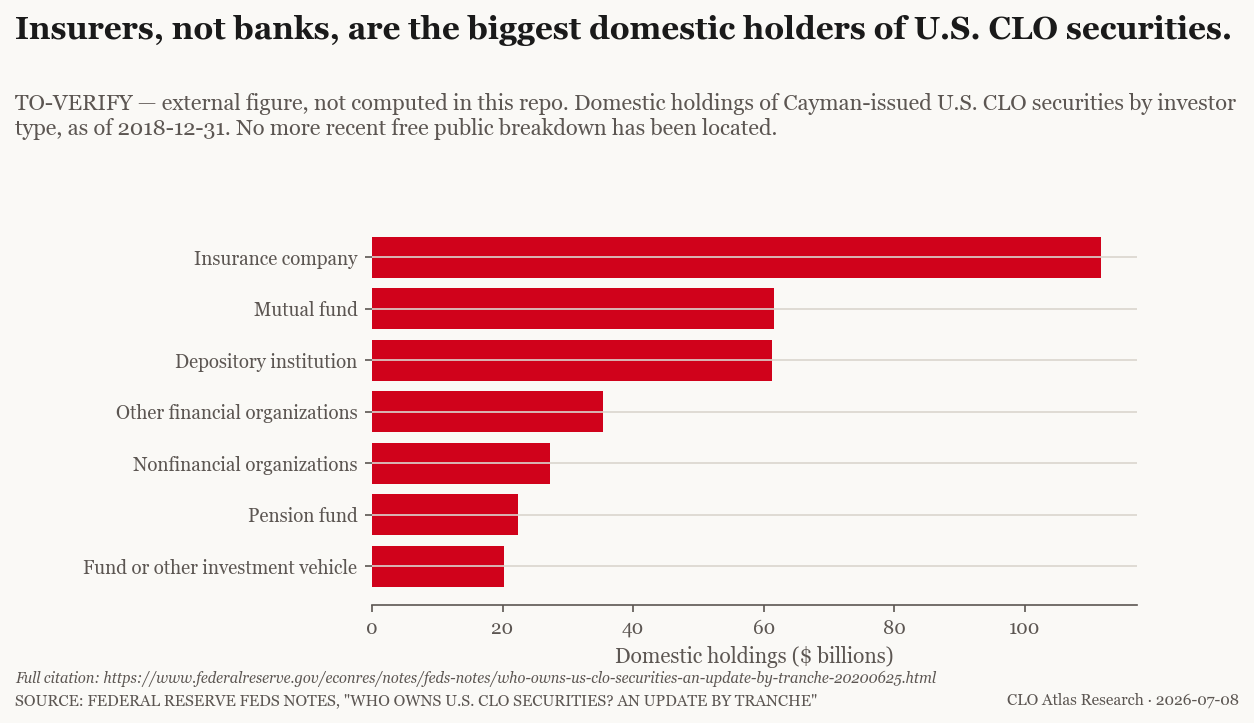

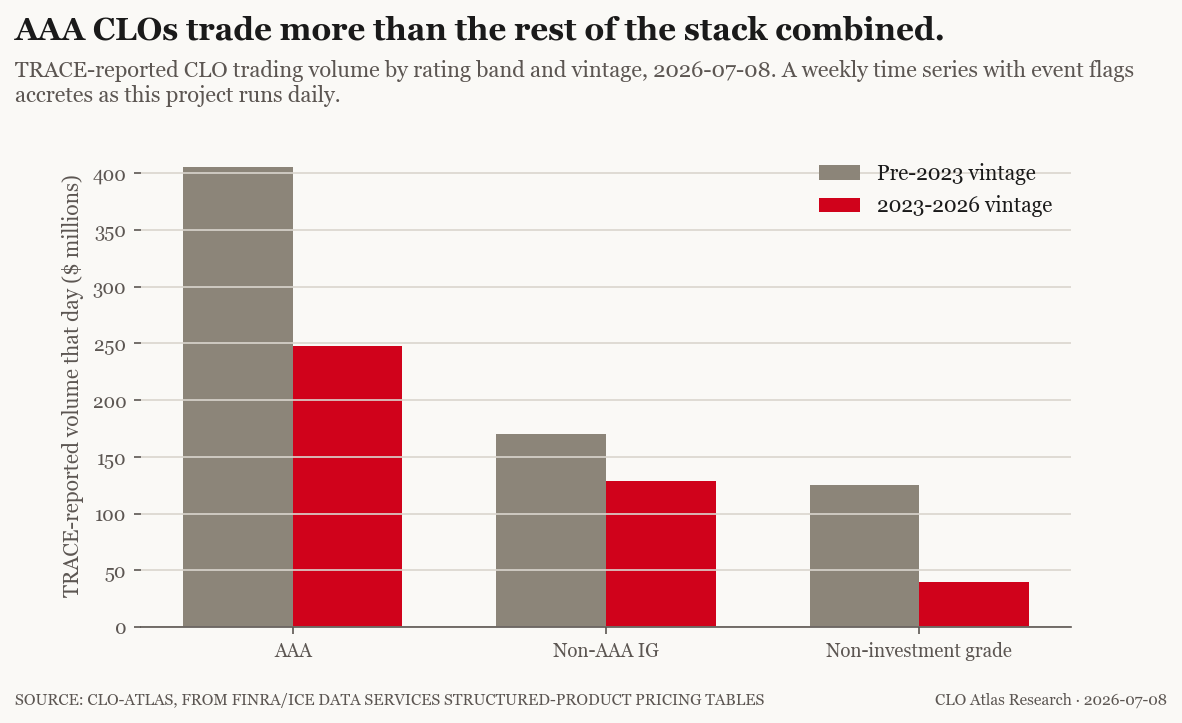

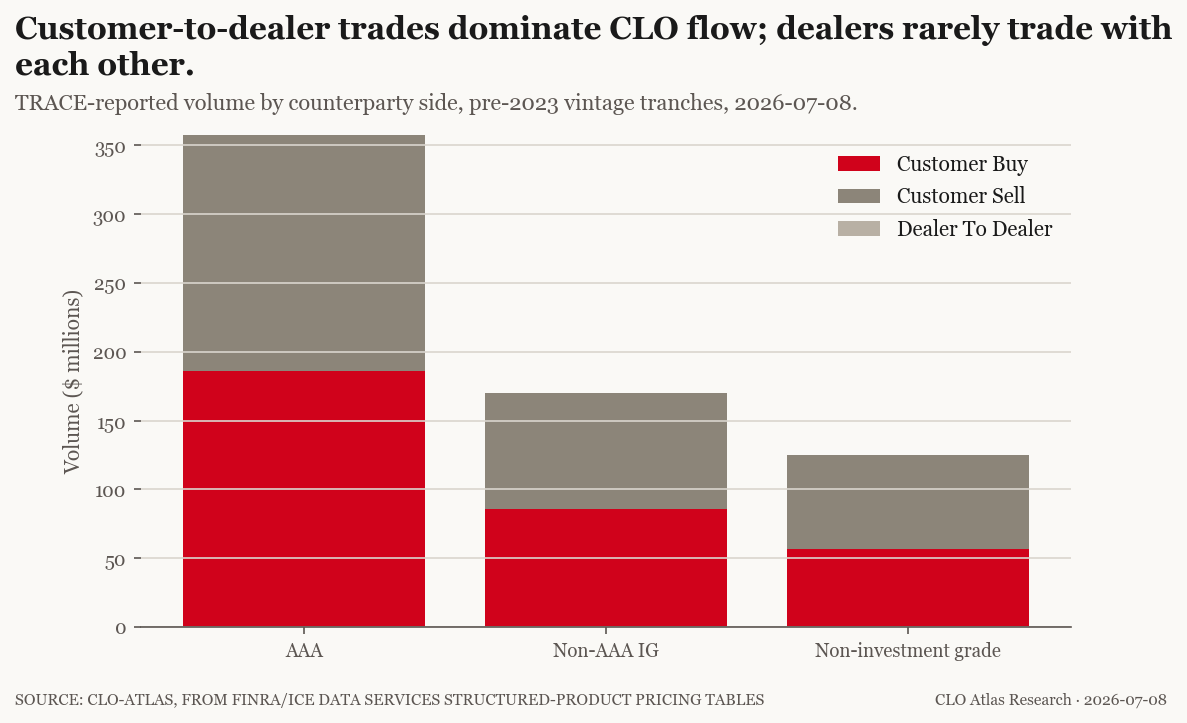

In [4]:
viz_holders.run()
viz_liquidity.run()
viz_issuance.run()

## Exhibits

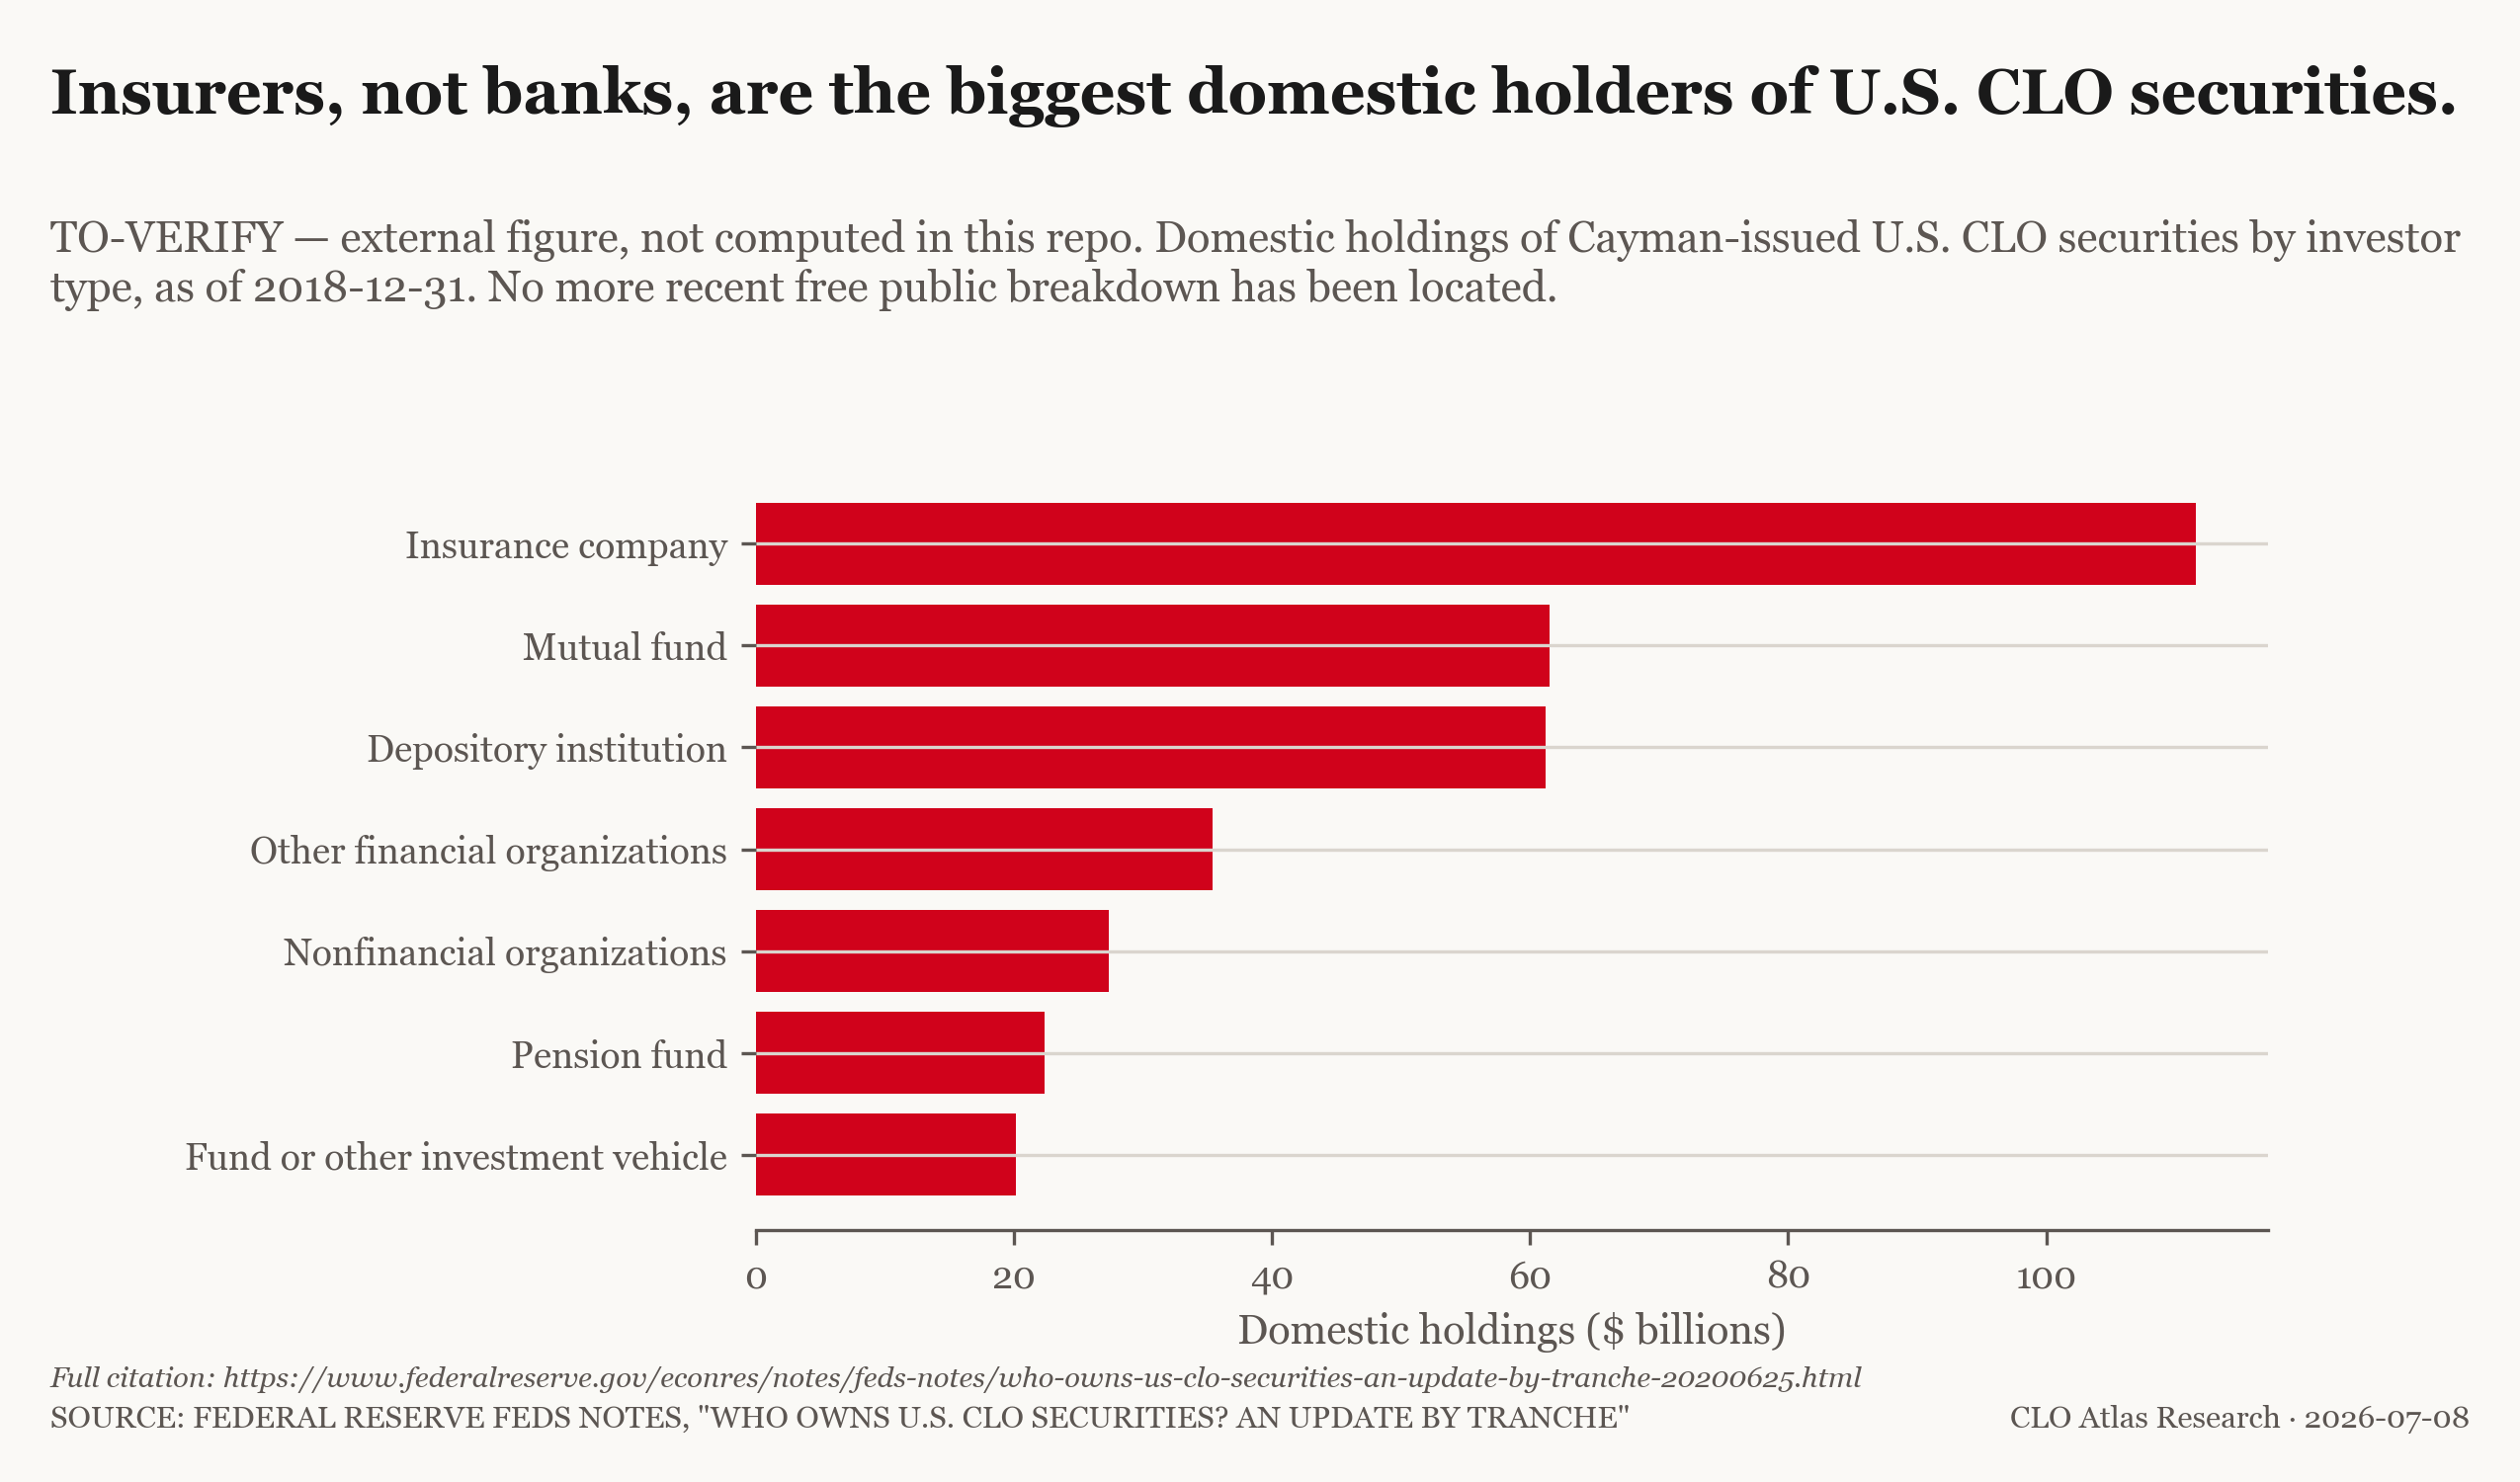

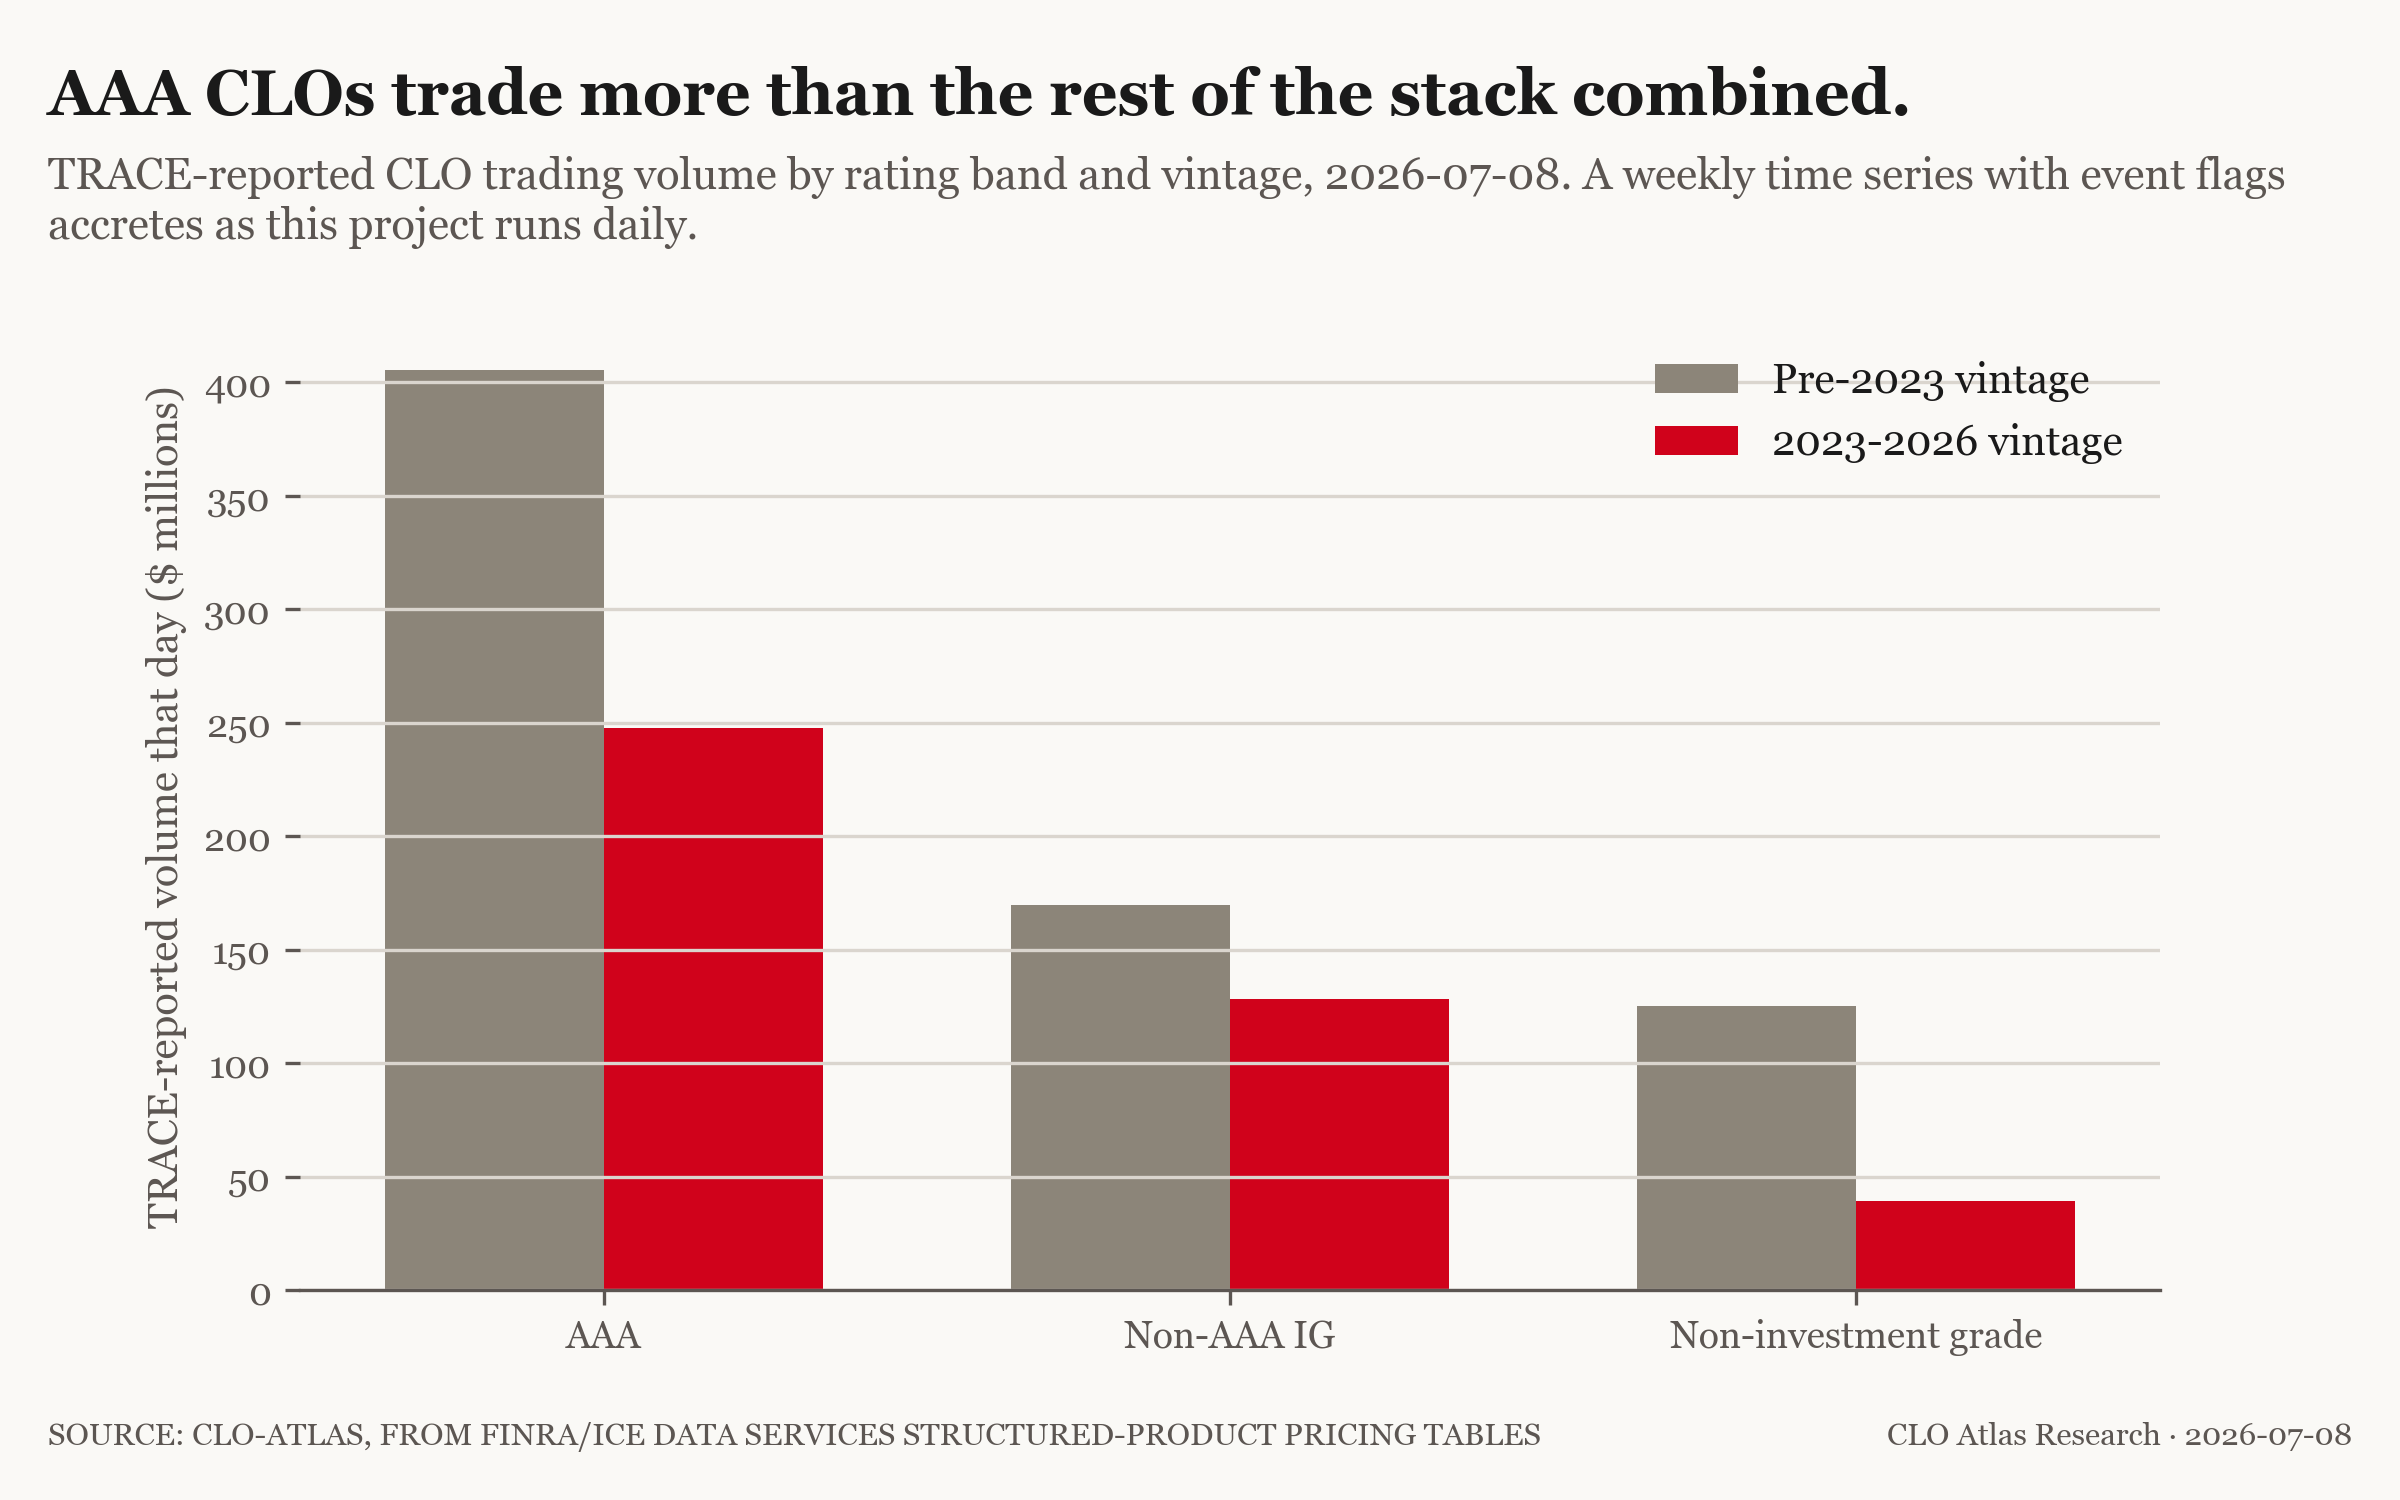

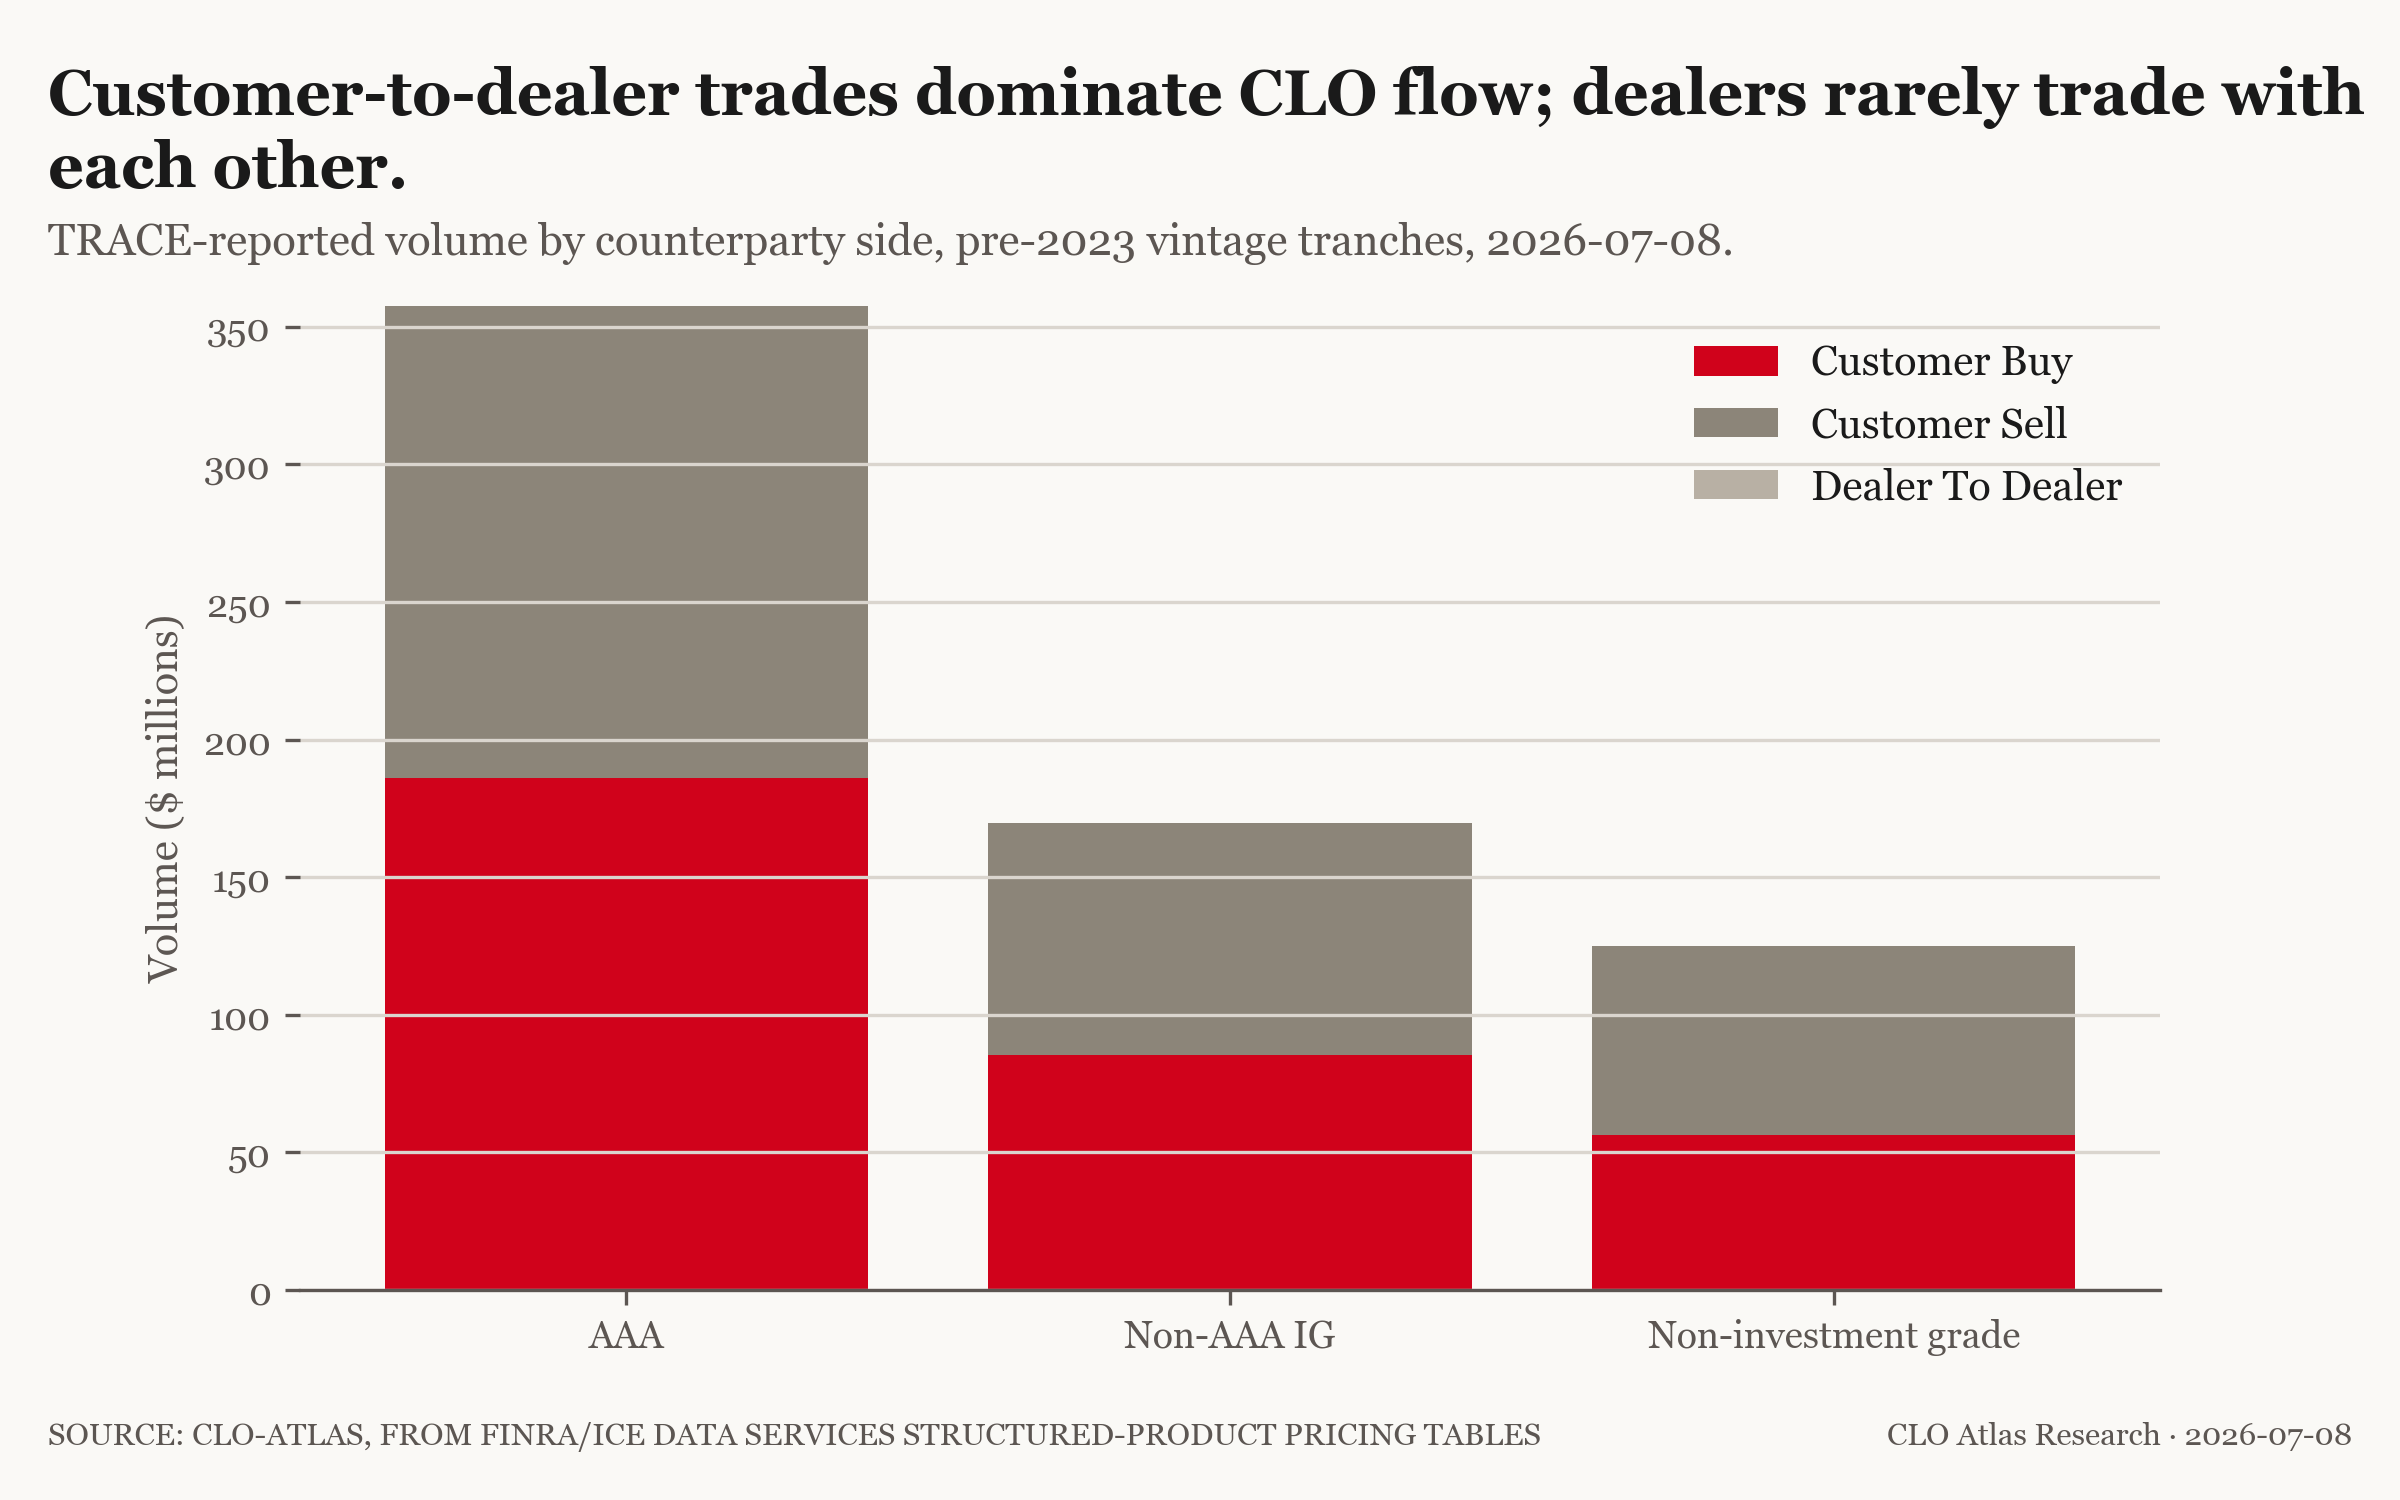

In [5]:
for name in ["viz_holder_composition", "viz_trace_volume_by_band", "viz_dealer_customer_split"]:
    path = pathlib.Path("../figures") / f"{name}.png"
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"[skipped — not generated this run] {name}")